In [1]:
import pandas as pd

df = pd.read_csv('CEAS_08.csv')
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
print(df.head())

Dataset Shape: (39154, 7)

Class Distribution:
label
1    21842
0    17312
Name: count, dtype: int64
                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                 Michael Parker <ivqrnai@pobox.com>   
4  Gretchen Suggs <externalsep1@loanofficertool.com>   

                                         receiver  \
0                     user4@gvc.ceas-challenge.cc   
1                   user2.2@gvc.ceas-challenge.cc   
2                   user2.9@gvc.ceas-challenge.cc   
3  SpamAssassin Dev <xrh@spamassassin.apache.org>   
4                   user2.2@gvc.ceas-challenge.cc   

                              date  \
0  Tue, 05 Aug 2008 16:31:02 -0700   
1  Tue, 05 Aug 2008 18:31:03 -0500   
2  Tue, 05 Aug 2008 20:28:00 -1200   
3  Tue, 05 Aug 2008 17:31:20 -0600   
4  Tue, 05 Aug 2008 19:31:21 -0400   

              

In [2]:
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

In [3]:
df['receiver'] = df['receiver'].fillna('')
df['subject']  = df['subject'].fillna('')

In [4]:
import numpy as np
import re
import urllib.parse
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy

nlp = spacy.load("en_core_web_sm")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
stop_words = set(stopwords.words('english'))


def extractMetadataFeatures(df):
    # Count URLs in body text or dedicated URL column
    df['url_count'] = df['body'].apply(lambda x: len(re.findall(r'https?://[^\s]+', str(x))))

    # Check for presence of urgency keywords in subject or body
    urgency_keywords = ['urgent', 'verify', 'account', 'bank', 'suspend', 'immediate', 'security', 'login']
    pattern = '|'.join(urgency_keywords)
    df['urgency_flag'] = df['subject'].str.contains(pattern, case=False).astype(int) | df['body'].str.contains(pattern, case=False).astype(int)

    # Text length features
    df['body_length'] = df['body'].apply(len)
    df['subject_length'] = df['subject'].apply(len)

    # Capitalization ratio (often higher in scam emails)
    df['uppercase_ratio'] = df['body'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    # Exclamation mark count
    df['exclamation_count'] = df['body'].apply(lambda x: x.count('!'))

    metadata_cols = ['url_count', 'urgency_flag', 'body_length', 'subject_length', 'uppercase_ratio', 'exclamation_count']
    return df[metadata_cols]


def extractWordEmbeddings(text_series, batch_size=200):
    vector_size = nlp("placeholder").vector.shape[0]

    texts = [str(t)[:1000] for t in text_series]
    embeddings = np.zeros((len(texts), vector_size), dtype='float32')

    non_empty_idx = [i for i, t in enumerate(texts) if t.strip()]
    non_empty_texts = (texts[i] for i in non_empty_idx)

    for idx, doc in zip(non_empty_idx, nlp.pipe(non_empty_texts, batch_size=batch_size)):
        vec = doc.vector
        if vec.shape[0] == vector_size:
            embeddings[idx] = vec

    return embeddings


def cleanText(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', str(text))
    # Remove URLs
    text = re.sub(r'https?://[^\s]+', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    cleanedTokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(cleanedTokens)


X_meta = extractMetadataFeatures(df)
df['cleaned_body'] = df['body'].apply(cleanText)

tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df['cleaned_body']).toarray()

X_embeddings = extractWordEmbeddings(df['cleaned_body'])

X_final = np.hstack([X_meta.values, X_tfidf, X_embeddings])
y = df['label'].values

print(f"Feature matrix shape: {X_final.shape}")
print(f"Target variable shape: {y.shape}")

Feature matrix shape: (39154, 3102)
Target variable shape: (39154,)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
}

results = []
trained_models = {}

print("\nStarting Model Training and Evaluation...\n" + "="*50)

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Save trained instance
    trained_models[name] = model
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
print("Training Models Completed!")


Starting Model Training and Evaluation...
Training Logistic Regression...
Training Naive Bayes...
Training Random Forest...
Training Neural Network (MLP)...
Training Models Completed!



MODEL PERFORMANCE COMPARISON
               Model  Accuracy  Precision   Recall  F1-Score
 Logistic Regression  0.990550   0.990409 0.992676  0.991541
         Naive Bayes  0.978547   0.989513 0.971847  0.980600
       Random Forest  0.979058   0.971942 0.991073  0.981414
Neural Network (MLP)  0.993232   0.994727 0.993133  0.993930

BEST MODEL SELECTED: Neural Network (MLP) (F1-Score: 0.9939)


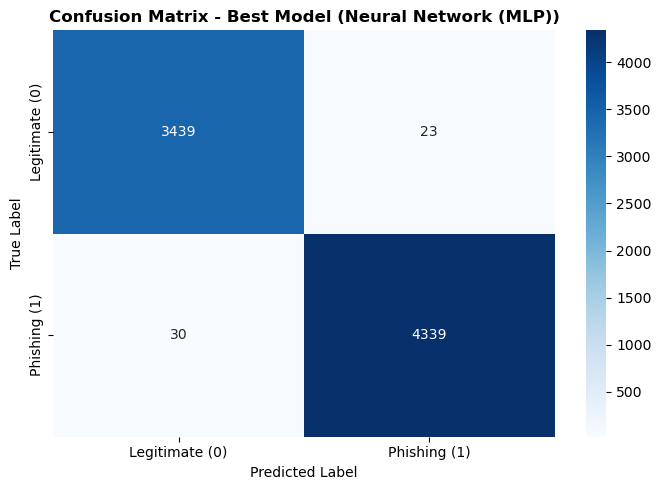


Classification Report for Neural Network (MLP):

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3462
    Phishing       0.99      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



In [6]:
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
print(results_df.to_string(index=False))

# Identify best model based on F1-Score
best_row = results_df.loc[results_df['F1-Score'].idxmax()]
best_model_name = best_row['Model']
best_model = trained_models[best_model_name]

print("\n" + "="*50)
print(f"BEST MODEL SELECTED: {best_model_name} (F1-Score: {best_row['F1-Score']:.4f})")
print("="*50)

y_best_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate (0)', 'Phishing (1)'],
            yticklabels=['Legitimate (0)', 'Phishing (1)'])

plt.title(f"Confusion Matrix - Best Model ({best_model_name})", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"\nClassification Report for {best_model_name}:\n")
print(classification_report(y_test, y_best_pred, target_names=['Legitimate', 'Phishing']))

Calculating Permutation Importance (Model-Agnostic)...


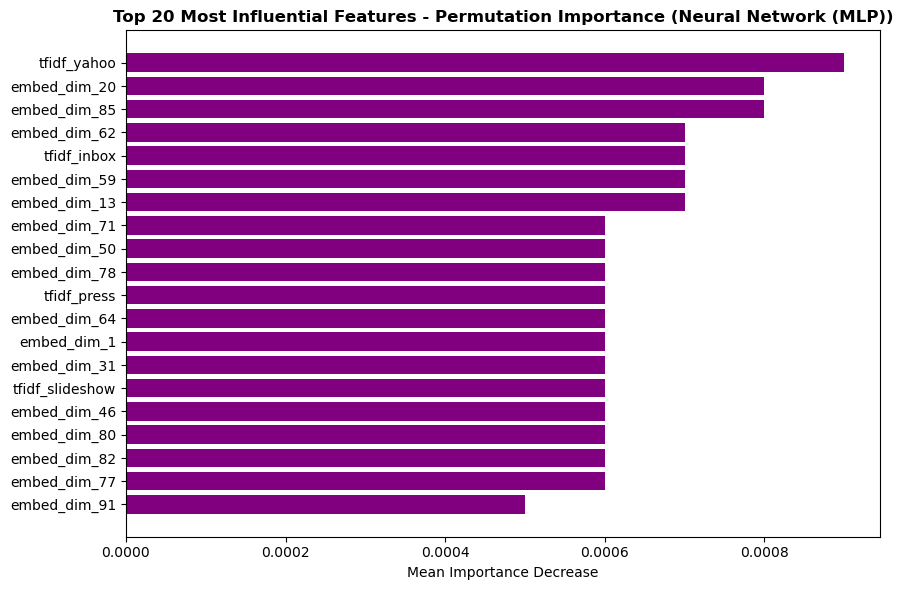


TOP 20 MOST INFLUENTIAL FEATURES (Neural Network (MLP))
        Feature  Importance / Weight   Feature Type
    tfidf_yahoo               0.0009         TF-IDF
   embed_dim_20               0.0008 Word Embedding
   embed_dim_85               0.0008 Word Embedding
   embed_dim_62               0.0007 Word Embedding
    tfidf_inbox               0.0007         TF-IDF
   embed_dim_13               0.0007 Word Embedding
   embed_dim_59               0.0007 Word Embedding
   embed_dim_71               0.0006 Word Embedding
   embed_dim_78               0.0006 Word Embedding
   embed_dim_50               0.0006 Word Embedding
   embed_dim_82               0.0006 Word Embedding
   embed_dim_46               0.0006 Word Embedding
    tfidf_press               0.0006         TF-IDF
   embed_dim_77               0.0006 Word Embedding
    embed_dim_1               0.0006 Word Embedding
   embed_dim_31               0.0006 Word Embedding
   embed_dim_80               0.0006 Word Embedding
   embe

In [7]:
from sklearn.inspection import permutation_importance

# Reconstruct feature list in exact order of concatenation
metadata_names = ['url_count', 'urgency_flag', 'body_length', 'subject_length', 'uppercase_ratio', 'exclamation_count']
tfidf_names = [f"tfidf_{word}" for word in tfidf.get_feature_names_out()]
embedding_names = [f"embed_dim_{i}" for i in range(X_embeddings.shape[1])]

feature_names = np.array(metadata_names + tfidf_names + embedding_names)

assert X_test_scaled.shape[1] == len(feature_names), (
    f"Feature count mismatch: X_test_scaled has {X_test_scaled.shape[1]} columns "
    f"but feature_names has {len(feature_names)}. Re-run cells 3-5 in order."
)

top_n = 20  # Top N features to display
print("Calculating Permutation Importance (Model-Agnostic)...")
n_perm_samples = min(2000, X_test_scaled.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_test_scaled.shape[0], size=n_perm_samples, replace=False)

perm_importance = permutation_importance(
    best_model,
    X_test_scaled[sample_idx],
    y_test[sample_idx],
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
importances = perm_importance.importances_mean
top_idx = np.argsort(importances)[-top_n:]

plt.figure(figsize=(9, 6))
plt.barh(feature_names[top_idx], importances[top_idx], color='purple')
plt.title(f"Top {top_n} Most Influential Features - Permutation Importance ({best_model_name})", fontsize=12, fontweight='bold')
plt.xlabel("Mean Importance Decrease")
plt.tight_layout()
plt.show()

top_overall_idx = np.argsort(np.abs(importances))[-top_n:][::-1]
summary_df = pd.DataFrame({
    'Feature': feature_names[top_overall_idx],
    'Importance / Weight': importances[top_overall_idx],
    'Feature Type': [
        'Metadata' if f in metadata_names else ('TF-IDF' if f.startswith('tfidf_') else 'Word Embedding')
        for f in feature_names[top_overall_idx]
    ]
})

print("\n" + "="*50)
print(f"TOP {top_n} MOST INFLUENTIAL FEATURES ({best_model_name})")
print("="*50)
print(summary_df.to_string(index=False))

In [8]:
def predict_email(subject, body, sender=""):
    # 1. Create a 1-row DataFrame mimicking the original structure
    sample_df = pd.DataFrame([{
        'subject': subject,
        'body': body,
        'sender': sender
    }])
    
    # 2. Extract Metadata Features (convert to numpy array using .values or extract row directly)
    meta_df = extractMetadataFeatures(sample_df)
    meta_feats = meta_df if isinstance(meta_df, np.ndarray) else meta_df.values
    
    # 3. Clean Text Body
    cleaned_body = sample_df['body'].apply(cleanText)
    
    # 4. Extract TF-IDF Features
    tfidf_feats = tfidf.transform(cleaned_body).toarray()
    
    # 5. Extract Word Embeddings
    embedding_feats = extractWordEmbeddings(cleaned_body)
    
    # 6. Stack all features into single array
    sample_final = np.hstack([meta_feats, tfidf_feats, embedding_feats])
    
    # 7. Scale features using the fitted scaler
    sample_scaled = scaler.transform(sample_final)
    
    # 8. Predict Class & Probability
    prediction = best_model.predict(sample_scaled)[0]
    probabilities = best_model.predict_proba(sample_scaled)[0] if hasattr(best_model, "predict_proba") else None
    
    # Display Results
    print("-"*10, "TEST RESULTS", "-"*10)
    
    label = "🚨 PHISHING DETECTED!" if prediction == 1 else "✅ LEGITIMATE (HAM)"
    print(f"PREDICTION: {label}")
    
    if probabilities is not None:
        confidence = probabilities[prediction] * 100
        print(f"CONFIDENCE: {confidence:.2f}%")
        print(f"  └─> Legitimate Prob: {probabilities[0]*100:.2f}%")
        print(f"  └─> Phishing Prob  : {probabilities[1]*100:.2f}%")
        
    print("-" * 60)
    print("DETECTED METADATA SIGNALS:")
    # Using row array values indexed safely
    print(f"  • URL Count         : {int(meta_feats[0][0])}")
    print(f"  • Urgency Keyword   : {'Yes' if meta_feats[0][1] == 1 else 'No'}")
    print(f"  • Exclamation Marks : {int(meta_feats[0][5])}")
    print(f"  • Uppercase Ratio   : {meta_feats[0][4]*100:.1f}%")
    print("=" * 60 + "\n")

In [9]:
# Test Case 1: Phishing Email Sample
phishing_sample_subject = "URGENT: Your Bank Account Has Been Suspended!"
phishing_sample_body = "Dear customer, we detected unusual login activity. Please click here immediately to verify your credentials: https://secure-bank-login-update.com/verify or your account will be permanently locked!"

# Test Case 2: Legitimate Email Sample
legit_sample_subject = "Project Update & Meeting Minutes"
legit_sample_body = "Hi team, please find attached the minutes from yesterday's discussion. Let me know if you have any questions regarding the roadmap before Friday."

print("Running Test Case 1 (Phishing Candidate)...")
predict_email(phishing_sample_subject, phishing_sample_body)

print("Running Test Case 2 (Legitimate Candidate)...")
predict_email(legit_sample_subject, legit_sample_body)

Running Test Case 1 (Phishing Candidate)...
---------- TEST RESULTS ----------
PREDICTION: 🚨 PHISHING DETECTED!
CONFIDENCE: 99.97%
  └─> Legitimate Prob: 0.03%
  └─> Phishing Prob  : 99.97%
------------------------------------------------------------
DETECTED METADATA SIGNALS:
  • URL Count         : 1
  • Urgency Keyword   : Yes
  • Exclamation Marks : 1
  • Uppercase Ratio   : 1.0%

Running Test Case 2 (Legitimate Candidate)...
---------- TEST RESULTS ----------
PREDICTION: ✅ LEGITIMATE (HAM)
CONFIDENCE: 97.16%
  └─> Legitimate Prob: 97.16%
  └─> Phishing Prob  : 2.84%
------------------------------------------------------------
DETECTED METADATA SIGNALS:
  • URL Count         : 0
  • Urgency Keyword   : No
  • Exclamation Marks : 0
  • Uppercase Ratio   : 2.1%



In [10]:
%run -i export_artifacts_cell.py

Artifacts saved to ./model_artifacts/
Copy this folder into the Flask app directory before running app.py
